# 🎙️ Voxtral Mini-4B — Tunisian Arabic ASR Benchmark

**Model:** `mistralai/Voxtral-Mini-4B-Realtime-2602`  
**Config key:** `voxtral`

> Voxtral is a realtime streaming ASR model.  
> We use: `processor(audio_list)` → `model.generate()` → `batch_decode()`  
> Requires `transformers >= 5.2.0`

## 1 · Install & Imports

In [1]:
!pip install -q datasets torchaudio evaluate jiwer pyyaml
!pip install --upgrade transformers
!pip install --upgrade "mistral-common[audio]"



In [2]:
import transformers
transformers.__version__

'5.7.0'

In [1]:
# Local path to benchmarking package
import sys
from pathlib import Path

BENCHMARK_ROOT = Path('/home/ala/dataset')
assert BENCHMARK_ROOT.exists(), f'Missing path: {BENCHMARK_ROOT}'

if str(BENCHMARK_ROOT) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_ROOT))

print('Using benchmark root:', BENCHMARK_ROOT)

Using benchmark root: /home/ala/dataset


In [2]:
from benchmark_utils import (
    load_config, get_device, print_gpu_info, setup_output_dir,
    load_benchmark, split_benchmark,
    compute_metrics, per_sample_wer,
    run_pipeline_inference, build_results_df,
    run_labelled_splits, run_unlabelled_splits,
    display_preview, display_worst, display_bulk_predictions,
    audio_inspector, display_summary, plot_wer_cer,
)
import numpy as np
import torch
import time
from pathlib import Path
from tqdm.auto import tqdm
from datasets import Audio as HFAudio

cfg = load_config(str(BENCHMARK_ROOT / 'config.yaml'))

# Override Colab-only paths for local execution
cfg['paths']['dataset'] = str(BENCHMARK_ROOT)
cfg['paths']['output_root'] = str(Path('/home/ala/TunisianDialogSystem/outputs/asr_benchmark_results'))

TARGET_SR    = cfg['evaluation']['target_sr']
TOP_N_WORST  = cfg['evaluation']['top_n_worst']
PREVIEW_ROWS = cfg['evaluation']['preview_rows']
RESUME = False

print('Dataset path:', cfg['paths']['dataset'])
print('Output root :', cfg['paths']['output_root'])

Dataset path: /home/ala/dataset
Output root : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results


## 2 · GPU Check

In [3]:
device = get_device()
print_gpu_info()

Device : cuda
GPU    : NVIDIA GB10
VRAM   : 128.5 GB total  |  128.5 GB free


## 3 · Load Model

In [4]:
import torch
from transformers import VoxtralRealtimeForConditionalGeneration, AutoProcessor
from transformers import AutoProcessor

mcfg        = cfg["models"]["voxtral"]
MODEL_ID    = mcfg["model_id"]
BATCH_SIZE  = mcfg["batch_size"]
OUTPUT_DIR  = setup_output_dir(cfg, "voxtral")
FILE_SUFFIX = "voxtral_results"

torch_dtype = torch.float16  # or torch.bfloat16 if your GPU supports it

print(f"Loading {MODEL_ID} ...")

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = VoxtralRealtimeForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map="auto",
)

model.eval()
print(f"✓ {MODEL_ID} loaded")

Loading mistralai/Voxtral-Mini-4B-Realtime-2602 ...


Loading weights:   0%|          | 0/711 [00:00<?, ?it/s]

✓ mistralai/Voxtral-Mini-4B-Realtime-2602 loaded


## 4 · Mount Drive & Load Benchmark

In [5]:
from datasets import DatasetDict, load_from_disk

# Build a DatasetDict from available on-disk split folders only
split_dirs = sorted([p for p in BENCHMARK_ROOT.iterdir() if p.is_dir()])
benchmark = DatasetDict()

for p in split_dirs:
    try:
        benchmark[p.name] = load_from_disk(str(p))
    except Exception:
        pass

print(f"Loaded splits: {list(benchmark.keys())}")
LABELLED_SPLITS, UNLABELLED_SPLITS = split_benchmark(benchmark)

Loaded splits: ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw', 'unlabeled_youtube']
Labelled splits   : ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw']
Unlabelled splits : ['unlabeled_youtube']


## 5 · Inference

In [6]:
def infer_fn(ds):
    ds = ds.cast_column("audio", HFAudio(sampling_rate=TARGET_SR))

    predictions, latencies = [], []
    start = time.time()

    for i in tqdm(range(0, len(ds), BATCH_SIZE), desc="Inferring", unit="batch"):
        batch = ds.select(range(i, min(i + BATCH_SIZE, len(ds))))

        audio_list = [
            np.array(x["audio"]["array"], dtype=np.float32)
            for x in batch
        ]

        t0 = time.time()

        inputs = processor(
            audio_list,
            sampling_rate=TARGET_SR,
            return_tensors="pt"
        )

        inputs = inputs.to(model.device, dtype=model.dtype)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=256)

        texts = processor.batch_decode(outputs, skip_special_tokens=True)

        elapsed = time.time() - t0
        per_s = elapsed / len(audio_list)

        predictions.extend(texts)
        latencies.extend([per_s] * len(texts))

    return predictions, latencies, time.time() - start


all_result_dfs, summary_rows = run_labelled_splits(
    benchmark,
    LABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    PREVIEW_ROWS,
    TOP_N_WORST,
)


  Running: labeled_algerian  (500 samples)


Inferring:   0%|          | 0/125 [00:00<?, ?batch/s]

  WER              : 0.8715
  CER              : 0.6483
  RTF              : 0.1332
  Total audio      : 3.987 h
  Inference time   : 1911.7 s
  Mean latency/smp : 3.8113 s
  Median latency   : 3.8095 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/labeled_algerian_voxtral_results.csv

  Running: labeled_linagora_cs_arabize  (5482 samples)


Inferring:   0%|          | 0/1371 [00:00<?, ?batch/s]

  WER              : 0.7787
  CER              : 0.5043
  RTF              : 0.3318
  Total audio      : 6.015 h
  Inference time   : 7184.2 s
  Mean latency/smp : 1.3091 s
  Median latency   : 1.0974 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/labeled_linagora_cs_arabize_voxtral_results.csv

  Running: labeled_linagora_raw  (5482 samples)


Inferring:   0%|          | 0/1371 [00:00<?, ?batch/s]

  WER              : 0.7541
  CER              : 0.4842
  RTF              : 0.3427
  Total audio      : 6.015 h
  Inference time   : 7421.7 s
  Mean latency/smp : 1.3524 s
  Median latency   : 1.1339 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/labeled_linagora_raw_voxtral_results.csv

✅ All labelled splits done.


## 6 · Per-sample preview

In [7]:
display_preview(all_result_dfs, PREVIEW_ROWS, extra_cols=['detected_language'])


── labeled_algerian ──


,reference,prediction,sample_wer,duration_s
0,في الدار البيضاء ومقاولات كبيرة بسبب الضبابية بسبب هاد الفراغ لي كاين ليوما على مستوى الاقتصاد السياسي واللي دخلنا في الركود التضخمي يعني التضخم دي اقتصادي هابط التراجع ديال النمو والشركات د القطاع الخصوصي الكبيرة كتكمن تقنن النفقات ديالها نقتاسم التوظيف وبالتالي يعني واحد السياسة احترازية,الضل البيضاء ومقاولات كبيرة بسبب الضبابية بسبب هذا الفراغ اللي كان اليوم على مستوى الاقتصاد السياسي ولدخنا في الركود تضخم يعني تضخم غادي والنمو الاقتصادي هبط تراجع دي النمو والشركات القطاع الخاص الكبيرة,0.630,30.000000
1,في ولا ولا هذا ولا هادشي لي كنت كنقرا وليت راسي كنتوجه الذكاء المالي التطور الشخصي انا دابا انا دابا بديت في التطور الشخصي قريت عليه وبديت كنت كنقرا وبغيت ندير التطور الشخصي ماشي باش نحل مشاكل الناس اللي مجوجين ديالك اه بغيت بغيت التطور الشخصي نخدمو فالتطور,"linguistics, socioeconomics, intercultural communication, soft skills, development,",1.000,28.650000
2,تكون التجربة ما عندهاش طعم وداك الانتقال من انك دكتور في الجامعة المغربية لأنك مدرب في الجامعة الدولية كي كان هاد الإنتقال وانا انا بديت يعني بديت العمل ديالي في جامعة خارج المغرب سواء في المملكة العربية السعودية وفي الإمارات او في الولايات المتحدة الأمريكية اه ولا كنت في طور يعني ده,تكون جريبة ما عنداش طعم وده كل انتقال من أنك دكتور في الجامعة المغربية لأنك مدرب في جامعة دولية كيف كان هذا الانتقال؟ وأنا بدأت العمل ديالي في جامعة خارج المغرب سواء في المملكة,0.615,29.250000
3,كاين واحد التعقيد يراد به واحد المجموعة د الأشياء فمن تم يعني درت الدكتوراه في الفين بديت في الفين وتلطاش سنة الفين وتمنطاش ومن تم يعني كذلك يعني طورت القضية ديال الاستشارات المالية التدقيق الشرعي ديال الأيوفي هيئة المراجعة والمحاسبة المعاملات المالية الإسلامية,"Si les gens savaient comment le système monétaire fonctionnait, il y aurait une révolution demain matin.",1.000,26.600000
4,ديال ديال كل واحد يديها فراسو حسن ليه من المشاكل نديها فراسي ناس جاب نشوف لاخر نشوف راسي انا المصلحة ديالي لا ولا هاد كيقولك اودي المسؤولية ديالهم توقع على الدولة هوما اللي هادي وهادي لا انا كنقول الذي يحرك هاد الرقي الاجتماعي هو منظومة القيم التي نعيشها,كل واحد يدها في راسه حسلي من المشاكل ده في راسي نجبنا نشوف لاخون نشوف راسي انا المصلحة دي لا ولا هاد الخطاب داعي وشائع,0.750,27.350000
5,غير معرفتش واش دابا نضحك ولا نكون معقول لي بغيت كنعرف يعني البرامج ديالك كيكون فيهم بزاف وانا معرفتش نكون المهم هو تعاودلي حكايتي عجبني العنوان شكرا كنهنئك واخا انا عرفت بان شهرزاد ديالي كانت كتحكي لشهر ايار لا بالعكس ماكاين تا مشكل توكلي على الله يالاه ها حنا غانمشيو,إدر معارف شو شيد بن نضحكوا لنكون معقول ممكن تعرف البرامج جرك يكون فيهم زفد اللي هو سريو وأنا ما نعرفش نكون سريو تعق تيري ما شتقول لك واحدة حاجة المهم وتعودي حكاية شكرا وخانا عرفت بينا شهر,0.920,28.150000
6,البناء اه بطبيعة الحال را الاعتدال مطلوب يعني ميمكنلناش نتصورو يعني اي بناء اولا توجه نحو التنمية بدون اعتدال لان لا الغلو ويضر والتراخي عاوتاني ايضا الغلو الدفاع مضر والتراخي ايضا مضر وبالتالي ان الاعتدال اساسي حنا المغرب منذ ثلاثة وتسعين والتوجه ديال المغرب في علاقة يعني القطع,البناء بطبيعة الحال العتيدة المطلوب يعني ممكنش نتصوره أي بناء أو توجه نحو التنمية بدون عتيدة لأن الغلو هو يضر والتراحي أيضا الغلو في الدفاع مضر والتراحي أيضا مضر وبالتالي أنا,0.708,27.650000
7,ديالكم حاولوا ما امكن تاخدوا مية فالمية ها حنا دابا وجدنا الأرض ديالنا اللي غادي ترتاح حتى الوقيتة ديال الربيع اللي خصنا نبداو نغرسوه الحاجة لي مهمة بزاف خصنا لي خصنا ناخدوهم هما الحمد لله دابا ولاو عندنا هاد فالمغرب للأسف مازال ما عندناش لي مية فالمية مغربيين ولكن اه نقدرو نلقاو لي,Le potager ديالكم حاولوا ما أمكان تاخذوا دي بخلط ميافلميا بيو احنا ده بوجدنا الارض ديانا اللي غادي ترتاح حتى لو قدي الربيع اللي خصنا بدنا نغصوفه حاجة اللي مهمة بزب خصنا ناخذوهم هما اللي جرين اللي جرين الحمد لله ده بوله عندنا دي استخبيوتار في المغرب للأسف ما زل ما عن,0.811,27.050000
8,كتخلص رسوم ديال التسجيل والتحفيض الى غير ذلك كتعلم ادارة الضرائب لأن كاين رسوم تسجيل كتأدى تاهو راه بمثابة اعلام واشعار الى غير ذلك ذلك اه اه كدلك خصنا نعلمو السلطة متلا ربما سكن ثانوي ولى سكن رئيسي وخا لأن الضريبة تختلي انا غادي نمشي نعلم فين غادي قلتي الجماعة نعم كاينة الجماعات وكاينة ادارة,شنت ضيف ال


── labeled_linagora_cs_arabize ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني س ديجا,أمضت مقتنعة ليتي تحب تبطل جسبك ولا مقتنعة ولا أي قعد معايا,1.000,7.776000
1,استفتاء,Stifte.,1.000,1.264000
2,يكري كرهبة,,1.000,0.880000
3,عبد الله مشى سال طفلة,,1.000,1.528000
4,هاذي غلطتي مش غلطتك,هذه غلط مش غلط,0.750,2.216000
5,بودكاستينق يت ماكس ماي داي على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و ذاي كير اباوت يو و يخمموا معناها,It makes my day. They care about you.,1.000,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كاس الحومة توا تشوف دنيا كيفاش تتقلب,يتفيو ذو خليق تروى إلى الإمارات تز حتى كيس الحومة تو تشوف الدنيا كيفش تتقلب,0.733,6.424000
7,عبد الله سال لمرا في القيشي,أبغى سلمنا فيه شيء,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد الي تبنا كوم آخر الي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كلكم ها قصر العدالة الجديد اللي تبناءكم اخي اللي هو خوك زيوكر بارك ربي فضله بنينا هالقصر ده البلو,0.727,8.712000
9,الي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000



── labeled_linagora_raw ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني c'إي déjà,أمضت مقتنعة ليتي تحب تبطل جسبك ولا مقتنعة ولا أي قعد معايا,1.000,7.776000
1,استفتاء,Stifte.,1.000,1.264000
2,يكري كرهبة,,1.000,0.880000
3,عبد الله مشى سأل طفلة,,1.000,1.528000
4,هذي غلطتي موش غلطتك,هذه غلط مش غلط,1.000,2.216000
5,podcasting it makes my day على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و they care about you و يخمموا معناها,It makes my day. They care about you.,0.846,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كأس الحومة توا تشوف دنيا كيفاش تتقلب,يتفيو ذو خليق تروى إلى الإمارات تز حتى كيس الحومة تو تشوف الدنيا كيفش تتقلب,0.733,6.424000
7,عبد الله سأل لمرا في القيشي,أبغى سلمنا فيه شيء,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد إلي تبنا كوم آخر إلي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كلكم ها قصر العدالة الجديد اللي تبناءكم اخي اللي هو خوك زيوكر بارك ربي فضله بنينا هالقصر ده البلو,0.727,8.712000
9,إلي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000


## 7 · Worst predictions

In [8]:
display_worst(all_result_dfs, TOP_N_WORST, extra_cols=['detected_language'])


── labeled_algerian — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
360,واحد ست شهور ولا عام وتخسر وترجع كموظف غدخل واحد طرات ليا انايا من الباطرون وولد الحاج الحاج اسميتو تال الغد ليه وليت داخل بحال بحال الناس كنباتي وندخل صعيبة اصاحبي والله الى صعيبة او وبقيت دوزت موظف كان كيما كيقولو كنداوي فهمتيني عند فهاديك مزيان من بعد,"Contra o Pronor e a Pondon, o Adeschor, o Leão, o Tixir, o Trazé, que é um mod, que é de colo, é de ser, que é de morada, é de prateleio, é de ousão, é de ousão, é de ousão. Trazé, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão, é de ousão.",2.000,30.000000
31,اللي كان اللي كان تنطيبو فالفران فالفران الخس تا هو طايب فالفران وتنعمل واحد باش تندير تناخد شوية ديال النشا تناخد شوية ديال تنطحنو تا تيرجع بحال وتندير شوية داك النشاط تندير بحالي بشوية ديال الحليب طبعا نباتي اهاه باش تا الناس اللي يقدروا ياكلوها تندير بحال,"Dikken, dikken, dan typen we voor de vrouw, dan open je de vrouw in de forrein, dan open je de vrouw in de forrein, en dan maak je een saus, zodat je het neemt. Dan neem je een diner, dan neem je een beurre van cajou, dan neem je het neer, dan neem je het beurre van cajou, en dan neem je het neer, dan neem je het samen, dan neem je het heleb, dan neem je",1.638,25.950000
419,وكنتأكد على واحد المسألة مهمة بزاف هو ان مكنتكلموش بزاف د الناس كيقوليك راه فاش غندير هدا خطأ ماشي كتنقص لينا من داك الكثافة را متنبقاوش نشوفو سميتو مكنبقاوش نشوفو الشعر كيما قلتي مغتقدرو تشوفو نتوما بديك العين المجردة طبيعي مكينش يشكل واحد المشكل جمالي بالنسبة غير مسألة اخيرة,"Exactement, de rappel, on a une question très importante, c'est qu'on ne parle pas beaucoup de gens qui disent qu'on ne va pas faire un grand laser, c'est une épilation définitive. C'est un erreur. Mais c'est une épilation définitive. C'est définitif. Exactement. Quand tu réduis même le casse-faire, tu ne vas pas vraiment voir ce qu'on fait. Tu ne vas pas voir ce qu'on fait. Tu ne vas pas voir ce qu'on fait. Tu ne vas pas voir ce",1.612,30.000000
210,اا دابا هي هادي مابقاش داكشي الناس مبقاتش كتبغي انها تكون بزاف تيبغيو هادوك كلشي كيبغيوك انه كيجي كاع مع انواع البشرات كيجي مع جميع انواع النساء اي وحدة كتقدر انها دير هاد هادشي كلو عندو قواعد خاصنا نحتارموها فالمراحل لاشياء اللي غادي نستعملوها قبل ما نبداو,"Effectivement, d'abord la tendance, il y a le make-up hadith, mais après je dis que je suis trop chargée, je ne me dis pas que je suis brille, que je suis maquillée de zèf. C'est vraiment que les filles maquillent, non maquillées. Make-up, non make-up. Tout ce qui est brille ou ce qui est bien, c'est que j'ai beaucoup d'énigmes de la peau, que j'ai beaucoup d'énigmes de la peau. Donc, toute personne peut",1.574,30.000000
56,اذا كان النظام المالي الاقتصادي ماشي اسلامي القوانين ماشي اسلاميين وبزاف د الحوايج اللي ماشي اسلاميين فميمكنش الناس تجي فلخر طالب انه ميكونش لواحد علماني راه اصلا نتا ملي درتي هاد الاسس اللي هوما كيتحكمو فينا كبشر ومادرتيهمش اصلا انت بديتي الماتش لبسة وحدة اخرى,كشطك من راسك وكتولي عندك ثقة في النفس انك تدير اي حاجة لو وصلت لهذا الحاجة فنقدر نوصل الحاجة اخرى يعني انا ردرش بزايف تحوي الزوينة وهذا اللي وصل باش فيتني انا باش حسن مني حسن منك بوال يعني عندنا عقل واحد تنجج عينين بنانيف يعني باش فيتني لاخر بنعيش وحيات وحدة يعني يرا هذيك شي اللي قدر يوصل لاخر ونقدر نوصل ليش انا ديري ز,1.444,30.000000
264,علاش لأن عارف انك غتمشي فين دابا ديال ديال ما يمشيو يصنعوا القناطر وهذا صديق ديالي وقعت له قالت لهم ونتا راه مشيتي خصنا للقناطر والشوارع شغادي دير لنا الفين ونص هادشي لي كيوقع كيمشيو ياخدو اذكى هاد الناس الناس وكيديوهم لهاد الميادين هاد الميدان كيعلمو باش يبدا يدير داكشي,"Helaas, in de haat van de casse-pied Paris 13, Dauphine, d'Abel et Zélèf, de la Polytechnique, au Lémineau Central, ou les grandes écoles de l'ingénieur, faut même choisir le canard, et c'est le frère de l'Ouagat. Il a dit, tu es le monsieur de l'école de Poinche, tu es le canard de l'Ouagat. Je vais te donner la finance. C'est le cas, il a p


── labeled_linagora_cs_arabize — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
1104,السلاطة,This is love.,3.000,0.568000
4942,الصومال,Es su mal.,3.000,1.253900
5070,صعيب,"Ça y est,",3.000,1.272000
283,ما زال معناتها,Look at my hair. Look at my hair.,2.667,1.744000
2293,الشكلاطة السخونة,You should know this corner.,2.500,0.992000
4551,راكش عاليوتوب راكش عاليوتوب,"Nick Schwab, on a dit tour, Rick is on YouTube.",2.500,2.820000
782,انا الي شفتو عليها يا سي امم,اللي شفتوا عليها يعنيها اتحب تقولي هذا الملخص ان كريت مرتك بامي عينيك تدخل دار دعارة وتخدم,2.429,9.056000
4466,نجم نوصلك شوية,Je pense que je vais y aller.,2.333,1.240000
1030,عاملهم صحاح كابيبون كابي,"Y'a plus bon, qu'a plus un malon, ma soeur.",2.250,2.613000
255,ومش وتولي اخيب و الي خليني نزيد نخنق اكثر ونخاف اكثر هو واني كنت حاس وكانه فمة حاجه مقابله وجهي سدت على نفس وقعدت تتنفس معايا كنت حاس باللي هو قدامي لكن في نفس الوقت مش قاعد راه في حتى شيء وقتها وين,"Au monsieur Toali. Ah, il est beau. Il est chaline, il est zid. Il est chneu, il est chneu. Il est chneu, il est chneu. Ah, oui, il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est",2.140,14.368000



── labeled_linagora_raw — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
1104,السلاطة,This is love.,3.000,0.568000
4942,الصومال,Es su mal.,3.000,1.253900
5070,صعيب,"Ça y est,",3.000,1.272000
283,ما زال معناتها,Look at my hair. Look at my hair.,2.667,1.744000
2293,الشكلاطة السخونة,You should know this corner.,2.500,0.992000
4551,راكش عاليوتوب راكش عاليوتوب,"Nick Schwab, on a dit tour, Rick is on YouTube.",2.500,2.820000
782,أنا إلي شفتو عليها يا سي إمم,اللي شفتوا عليها يعنيها اتحب تقولي هذا الملخص ان كريت مرتك بامي عينيك تدخل دار دعارة وتخدم,2.429,9.056000
4466,نجم نوصلك شوية,Je pense que je vais y aller.,2.333,1.240000
1030,عاملهم صحاح CAPIBON CAPI,"Y'a plus bon, qu'a plus un malon, ma soeur.",2.250,2.613000
255,ومش وتولي اخيب و إلي خليني نزيد نخنق اكثر ونخاف اكثر هو واني كنت حاس وكانه فمة حاجه مقابله وجهي سدت على نفس وقعدت تتنفس معايا كنت حاس باللي هو قدامي لكن في نفس الوقت مش قاعد راه في حتى شيء وقتها وين,"Au monsieur Toali. Ah, il est beau. Il est chaline, il est zid. Il est chneu, il est chneu. Il est chneu, il est chneu. Ah, oui, il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est chneu. Il est",2.140,14.368000


## 8 · Unlabelled inspection

In [9]:
unlabelled_result_dfs = run_unlabelled_splits(
    benchmark,
    UNLABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    resume=RESUME,
)


  Running (unlabelled): unlabeled_youtube  (398 samples)


Inferring:   0%|          | 0/100 [00:00<?, ?batch/s]

  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/unlabeled_youtube_voxtral_results.csv

✅ All unlabelled splits done.


In [10]:
audio_inspector(
    benchmark,
    unlabelled_result_dfs,
    UNLABELLED_SPLITS,
    target_sr=TARGET_SR,
    extra_df_cols=['detected_language'],
)

In [11]:
display_bulk_predictions(unlabelled_result_dfs, extra_cols=['detected_language'])


── unlabeled_youtube — all 398 predictions ──


,prediction,duration_s,audio_id,source_url,seg_start,seg_end
0,إدارة الصيدلة والأدوية بوزارة الصحة تقرر سحب أربعة مكملات غذائية من السوق لعدم تطابقها مع المواصفات خبر قد يعتبر في ظاهره عادياً لكنه يخفي مشاكل كبرى تتعلق,14.976000,MDU2ROgeKns_0,https://www.youtube.com/watch?v=MDU2ROgeKns,0.000000,15.000000
1,مساحة التونسي في هذه المواد نجدها معروضة في مسالك أخرى غير الصيدليات حيث أنها تباع ويروج لها عبر الانترنت ومواقع التواصل الاجتماعي لما سمعت اللي وقع سحب بعض المكمل,15.000000,MDU2ROgeKns_1,https://www.youtube.com/watch?v=MDU2ROgeKns,15.000000,30.000000
2,الغذائية تبقى المواقع الواب اللي هم يبيعوا في الأشياء هذه في الحقيقة أنا ما ندورش بيهم كنت نشري الحق ويظهر لي حاجة بيها ما فا توكيل الوزارة كما قال منعته منعته,15.000000,MDU2ROgeKns_2,https://www.youtube.com/watch?v=MDU2ROgeKns,30.000000,45.000000
3,مناشنا معارفين الشي هذي؟ الشكن بالمكملات الغذائية اللي مصنوعة في تونس اللي النجم نقاع في الصيديات ولا النجم نقاع في أي موقع تجاري آخر ولا حتى في مواقع التواصل الاجتماعي ولا على الانترنت فما اشكال كبير في المكملات الغذائية,15.000000,MDU2ROgeKns_3,https://www.youtube.com/watch?v=MDU2ROgeKns,45.000000,60.000000
4,اصفاء محلية اللي الجودة متاعها تنجم في بعض الحالات ما يكونوش جيدة المصنعين المحليين ما يقطعوا حتى قانون ولاحظوا اللي برشة موجهين الأطفال وهذي يختار الصافي على الصحت الصغير اليوم عنا هذوما اللي سحبتهم,15.000000,MDU2ROgeKns_4,https://www.youtube.com/watch?v=MDU2ROgeKns,60.000000,75.000000
5,صحة لكن زيدة فيما في أريانة زيدة اكتشفوا اللي فيما محل غير مؤهل لصناعة المواد هذه وقعت يصنع في بعض الحاجات اللي هي موجهة خاصة للأطفال منظمة الدفاع عن المستهلك أكدت تلقيها,14.896000,MDU2ROgeKns_5,https://www.youtube.com/watch?v=MDU2ROgeKns,75.000000,90.000000
6,هذه شكية من عديد المواطنين تعرضوا لعمليات تحييل عند اقتناء مكملات غذائية من مواقع الانترنت في وقت تطالب خلاله نقابة أصحاب الصيدريات الخاصة وزارة الصحة بتفعيل القانون المنظم لهذا القطاع,14.840000,MDU2ROgeKns_6,https://www.youtube.com/watch?v=MDU2ROgeKns,90.000000,105.000000
7,اليوم القانون موجود في رفوف وزارة الصحة ما صدرش القانون هذه هو أمر حكومي الأمر الحكومي هذه متفق عليه من طرف جميع المداخلين في القطاع ما فهمنيش عليش لتو ما خرجش الأمر الحكومي هذه في غياب القانون فما غياب للمخالفات,14.904000,MDU2ROgeKns_7,https://www.youtube.com/watch?v=MDU2ROgeKns,105.000000,120.000000
8,غياب المراخبة اليوم يجب أن تعمل لهم حتى شيء حتى في الصناعة وإلا في التوسيع المكملة الغذائية صحيحة مع ميهاب هي لكن مذبينها زيدا ناخدونا سيحة الطبيب المباشر متاعنا إقبال على المواد هذه,14.992000,MDU2ROgeKns_8,https://www.youtube.com/watch?v=MDU2ROgeKns,120.000000,135.000000
9,ونأكد ونأكد هنا ونعود قديش احنا كمنظمة تشكياج المنظمة اشكيات من على اساس وقع اقتناء على اساس مكملات غذائية وكانت مواد تسبت لبرشة مشاكل صحية هوني دعوة الى التول,15.000000,MDU2ROgeKns_9,https://www.youtube.com/watch?v=MDU2ROgeKns,135.000000,150.000000


## 9 · Summary

In [12]:
summary_df = display_summary(
    summary_rows,
    OUTPUT_DIR,
    FILE_SUFFIX,
    "Voxtral-Mini-4B"
)

,dataset,n_samples,total_audio_h,WER,CER,RTF,inference_time_s,mean_latency_s,median_latency_s
0,labeled_algerian,500,3.987,0.8715,0.6483,0.1332,1911.7,3.8113,3.8095
1,labeled_linagora_cs_arabize,5482,6.015,0.7787,0.5043,0.3318,7184.2,1.3091,1.0974
2,labeled_linagora_raw,5482,6.015,0.7541,0.4842,0.3427,7421.7,1.3524,1.1339



✓ Summary saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/voxtral_results_benchmark_summary.csv

--------------------------------------------------
  Macro-avg WER : 0.8014
  Macro-avg CER : 0.5456
  Total audio   : 16.017 h
  Output dir    : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results


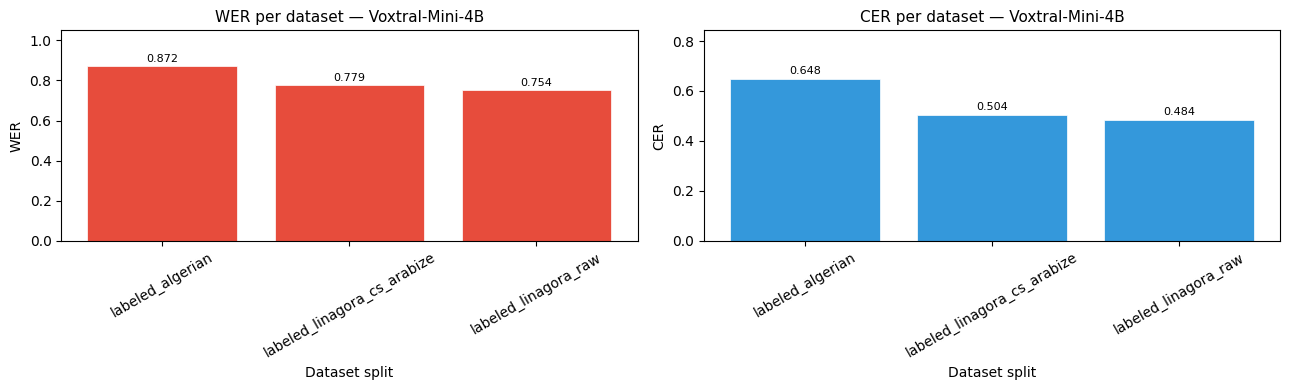

✓ Chart saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/voxtral_results/voxtral_results_wer_cer_chart.png


In [13]:
if summary_df is not None:
    plot_wer_cer(
        summary_df,
        OUTPUT_DIR,
        FILE_SUFFIX,
        "Voxtral-Mini-4B"
    )